# Raspberry PhenoSet — pretrained YOLOv8-X phenology-stage detection and test-set validation

Reproduction of the detection benchmark in **"Phenology-based learning framework for yield estimation and harvest forecasting of raspberry fruits"** (Jafary et al., arXiv:2411.00967; journal version DOI 10.1007/s41315-026-00564-5).

**Scope (this notebook):** load the authors' pretrained YOLOv8-X detector (`YOLOv8-X/weights/best.pt`, commit `732dd020b1b8`), run the author-documented inference settings (`inference_ultralytics.py`: `imgsz=896, conf=0.2, iou=0.8`) on a few Raspberry PhenoSet **test** images, and validate on the released 278-image test split (273 image/label pairs) to compare against the paper's Table V row (Precision 0.721, Recall 0.668, AP50 0.717, mAP50-95 0.550, F1 0.693) and per-class Table VI. Seven BBCH-aligned phenology stages A–G: A floral bud; B open flower; C green fruit initiation; D green fruit; E colour changing to yellow; F semi-mature pink; G mature red.

**Not reproduced here:** training of the 11 benchmark configurations, segmentation models, and the v2-only field test (92.2% field accuracy, 28–33 day harvest forecasting) — the v2 body is not readable as text and those results are evidenced only from the abstract/authors' site. Training is out of scope: this is the inference-first minimal reproduction.

日本語の要約: 著者公開済みの YOLOv8-X 重みを読み込み、Raspberry PhenoSet のテスト画像数枚で推論（可視化）し、公開されている 278 枚のテスト分割（273 組の画像/ラベル対）で検証して論文 Table V の値（P 0.721, R 0.668, AP50 0.717, mAP50-95 0.550, F1 0.693）と比較します。学習・セグメンテーション・v2 の圃場実験は対象外です。

## Runtime selection

**Recommended: GPU (T4)** — measured in the diagnostic run: full test-split validation takes ≈30 s on a T4; per-image inference at the author settings is ≈9 s cold / well under a second warm. CPU also works end to end (≈4 s per inference image; validation and downloads stretch the total to roughly 15–25 minutes). The notebook auto-detects the device and keeps the sample, weights, and settings identical on both.

**Run all:** Runtime → Run all. Downloads: `best.pt` (≈137 MB), `labels.zip` (≈2.9 MB), and 278 low-resolution test images (≈40 KB each). Expect ≈10 minutes end to end on T4, longer on CPU.

日本語: GPU(T4) 推奨（検証は約 30 秒）。CPU でも動作しますが合計 15〜25 分程度かかります。ランタイム → すべてのセルを実行。ダウンロード合計は約 200 MB 未満です。

## 1. Setup — install Ultralytics

The authors' `environment.yml` uses PyTorch 2.0 + CUDA 11.8, but Colab's preinstalled PyTorch is sufficient for inference and validation. We pin the Ultralytics version validated for this run so the 2024 checkpoint loads deterministically.

In [ ]:
import sys
# 'ultralytics' pulls in torch/torchvision/opencv if missing (Colab has torch preinstalled)
!"{sys.executable}" -m pip install -q "ultralytics==8.4.174" "gdown>=5"
import ultralytics, torch
print('ultralytics', ultralytics.__version__, '| torch', torch.__version__)
DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE, '-', torch.cuda.get_device_name(0) if DEVICE == 0 else 'CPU')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.6 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 11.9 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


ultralytics 8.4.174 | torch 2.11.0+cu130
device: 0 - Tesla T4


## 2. Load the authors' pretrained YOLOv8-X checkpoint

Downloaded from the author repository's Git LFS storage at the pinned commit `732dd020b1b8` and verified against the recorded SHA-256 and size (from the repository's LFS pointer metadata). This is the exact `best.pt` the authors released under `YOLOv8-X/weights/` — no substitute weights are used.

In [ ]:
import urllib.request, hashlib, os
URL = 'https://media.githubusercontent.com/media/pjafary/RaspberryPhenoSet/732dd020b1b85856417a517e08ce232a83e89074/YOLOv8-X/weights/best.pt'
EXPECTED_SHA256 = 'f109b269dc3cbc11ccbc5ef8e80e0c8447d0fa136b151c33631a62d6036a7e5a'
EXPECTED_SIZE = 136712446
os.makedirs('/content/PhenoSet', exist_ok=True)
if not (os.path.exists('/content/PhenoSet/best.pt') and os.path.getsize('/content/PhenoSet/best.pt') == EXPECTED_SIZE):
    urllib.request.urlretrieve(URL, '/content/PhenoSet/best.pt')
h = hashlib.sha256(open('/content/PhenoSet/best.pt', 'rb').read()).hexdigest()
print('sha256:', h)
assert h == EXPECTED_SHA256 and os.path.getsize('/content/PhenoSet/best.pt') == EXPECTED_SIZE
print('checkpoint verified:', os.path.getsize('/content/PhenoSet/best.pt'), 'bytes')

sha256: f109b269dc3cbc11ccbc5ef8e80e0c8447d0fa136b151c33631a62d6036a7e5a
checkpoint verified: 136712446 bytes


### Class names from the checkpoint metadata

The stage names A–G are read from the checkpoint itself (not invented); the paper's Sec. III defines A floral bud → G mature red fruit.

In [ ]:
from ultralytics import YOLO
model = YOLO('/content/PhenoSet/best.pt')
print('task:', model.task)
print('class names:', model.names)
assert model.task == 'detect' and set(model.names.values()) == set('ABCDEFG')

task: detect
class names: {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G'}


## 3. Acquire the Raspberry PhenoSet test split (low-resolution version)

The authors host the dataset on a public Google Drive folder. The **low.resolution(resized)** version was produced by the authors for mid-class GPUs (RTX 3060); we use it to keep downloads small. From it we need only:

- `labels.zip` (≈2.9 MB) — contains the authors' pre-split YOLO label folders `train/`, `val/`, `test/` plus COCO-format JSONs, and
- the 278 images in `images/test/` — the authors' released test split (the paper describes a 70/15/15 split of 1,853 images per Sec. III; the release ships 278 test images, 274 of them with label files).

File IDs are resolved from the public folder listing at runtime (no hardcoded IDs except the pinned top folder `1JAGpBIL9U9l…`).

In [ ]:
import gdown, requests, re, html as ihtml
TOP_FOLDER = '1JAGpBIL9U9lws-CtDmU66TnVs_fc8T4M'
gdown.download(id='1zBjJnp1MfPxEywNIfD8QHgxyWtrvzIRG', output='/content/labels.zip', quiet=False)

def list_folder(fid):
    r = requests.get(f'https://drive.google.com/embeddedfolderview?id={fid}#list', timeout=60)
    r.raise_for_status()
    ids = re.findall(r'flip-entry" id="entry-([\w-]+)"', r.text)
    titles = re.findall(r'flip-entry-title">(.*?)</div>', r.text, re.S)
    return list(zip(ids, [ihtml.unescape(t) for t in titles]))

lowres = list_folder(TOP_FOLDER)
print('low.resolution(resized):', [n for _, n in lowres])
images_fid = dict((n, i) for i, n in lowres)['images']
test_fid = dict((n, i) for i, n in list_folder(images_fid))['test']
test_images = list_folder(test_fid)
print('images/test entries:', len(test_images))
import json, collections
print(collections.Counter(n.rsplit('.', 1)[-1] for _, n in test_images))
json.dump(test_images, open('/content/PhenoSet/test_images.json', 'w'))

Downloading...
From: https://drive.google.com/uc?id=1zBjJnp1MfPxEywNIfD8QHgxyWtrvzIRG
To: /content/labels.zip


  0%|          | 0.00/2.86M [00:00<?, ?B/s]

100%|██████████| 2.86M/2.86M [00:00<00:00, 174MB/s]

low.resolution(resized): ['images', 'labels.zip']


images/test entries: 278
Counter({'JPG': 278})


Download the 278 released test images with a small parallel pool and bounded per-file retries, then verify count and JPEG validity. Each file is ≈40 KB; expect 1–4 minutes.

In [ ]:
import os, json, random
from concurrent.futures import ThreadPoolExecutor
from PIL import Image
import gdown

test_images = [tuple(x) for x in json.load(open('/content/PhenoSet/test_images.json'))]
os.makedirs('/content/PhenoSet/images/test', exist_ok=True)

def fetch(eid_name):
    eid, name = eid_name
    dst = f'/content/PhenoSet/images/test/{name}'
    if os.path.exists(dst) and os.path.getsize(dst) > 0:
        return name, True
    for attempt in range(3):
        try:
            gdown.download(id=eid, output=dst, quiet=True)
            if os.path.exists(dst) and os.path.getsize(dst) > 0:
                return name, True
        except Exception:
            pass
    return name, False

with ThreadPoolExecutor(max_workers=8) as ex:
    results = list(ex.map(fetch, test_images))
failed = [n for n, ok in results if not ok]
print('downloaded:', len(test_images) - len(failed), 'of', len(test_images), '| failed:', failed[:5])
assert not failed, f'unretrieved test images: {failed}'
files = sorted(os.listdir('/content/PhenoSet/images/test'))
bad = []
for f in random.sample(files, min(10, len(files))):
    im = Image.open(f'/content/PhenoSet/images/test/{f}'); im.load()
    bad.append((f, im.format, im.size))
print('sample validity:', bad)

downloaded: 278 of 278 | failed: []
sample validity: [('A (158).JPG', 'JPEG', (900, 600)), ('B (217).JPG', 'JPEG', (900, 600)), ('F (30).JPG', 'JPEG', (900, 600)), ('B (75).JPG', 'JPEG', (900, 600)), ('B (76).JPG', 'JPEG', (900, 600)), ('F (129).JPG', 'JPEG', (900, 600)), ('C (352).JPG', 'JPEG', (900, 600)), ('C (33).JPG', 'JPEG', (900, 600)), ('D (1).JPG', 'JPEG', (900, 600)), ('B (318).JPG', 'JPEG', (900, 600))]


Extract the label folders and write the Ultralytics `data.yaml`. Label files are named `<Stage> (<n>).txt` and pair with same-stem images; class indices 0–6 map to stages A–G via the checkpoint metadata. The authors' release contains 278 test images but only 274 label files: images `G (40)`–`G (44)` ship without labels (treated as background), label `G (34).txt` has no matching image, and one label file (`B (436).JPG`) contains duplicate boxes that Ultralytics removes with a warning. We verify the stem pairing before validating.

In [ ]:
import zipfile, os, glob, shutil
with zipfile.ZipFile('/content/labels.zip') as z:
    z.extractall('/content/PhenoSet/labels_zip')
for split in ('train', 'val', 'test'):
    n = len(glob.glob(f'/content/PhenoSet/labels_zip/{split}/*.txt'))
    print(split, 'label files:', n)
shutil.copytree('/content/PhenoSet/labels_zip/test', '/content/PhenoSet/labels/test', dirs_exist_ok=True)

img_stems = {os.path.splitext(f)[0] for f in os.listdir('/content/PhenoSet/images/test')}
lbl_stems = {os.path.splitext(f)[0] for f in os.listdir('/content/PhenoSet/labels/test')}
print('paired stems:', len(img_stems & lbl_stems), '/', len(img_stems), 'images;', len(lbl_stems), 'labels')
print('images without labels:', sorted(img_stems - lbl_stems))
print('labels without images:', sorted(lbl_stems - img_stems))

yaml_text = f'''path: /content/PhenoSet
train: images/train  # not downloaded in this notebook (inference-first scope)
val: images/val      # not downloaded in this notebook (inference-first scope)
test: images/test
names:
'''
for k, v in model.names.items():
    yaml_text += f'  {k}: {v}\n'
open('/content/PhenoSet/data.yaml', 'w').write(yaml_text)
print(yaml_text)

train label files: 1301
val label files: 278
test label files: 274
paired stems: 273 / 278 images; 274 labels
images without labels: ['G (40)', 'G (41)', 'G (42)', 'G (43)', 'G (44)']
labels without images: ['G (34)']
path: /content/PhenoSet
train: images/train  # not downloaded in this notebook (inference-first scope)
val: images/val      # not downloaded in this notebook (inference-first scope)
test: images/test
names:
  0: A
  1: B
  2: C
  3: D
  4: E
  5: F
  6: G



## 4. Input preview — reference annotations drawn from the authors' labels

Before any model output, we display one test image with its **reference (human) annotations** read from the authors' test label file — this is ground truth, not a prediction. Coordinates are normalized YOLO `(class, cx, cy, w, h)`, so boxes are scaled by image width/height. We deterministically pick three test labels with several instances (for a readable demo) and use the first as the preview image.

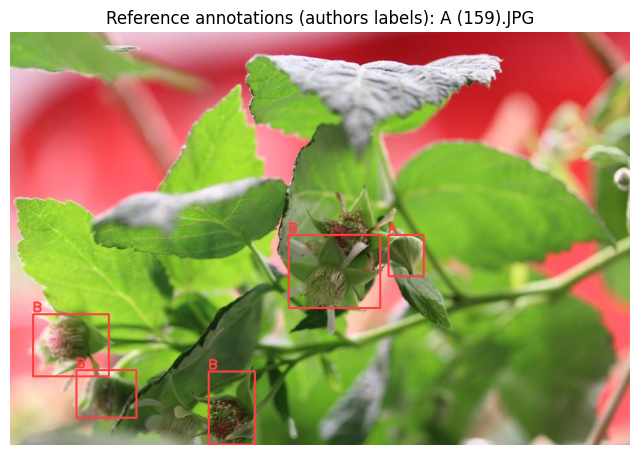

demo stems: ['A (159)', 'A (160)', 'A (161)']


In [ ]:
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

def draw_yolo_labels(img_path, lbl_path, names):
    im = cv2.imread(img_path)[:, :, ::-1].copy()
    H, W = im.shape[:2]
    for line in open(lbl_path):
        parts = line.split()
        if len(parts) != 5:
            continue
        c, cx, cy, w, h = int(parts[0]), *map(float, parts[1:])
        x1, y1 = int((cx - w / 2) * W), int((cy - h / 2) * H)
        x2, y2 = int((cx + w / 2) * W), int((cy + h / 2) * H)
        cv2.rectangle(im, (x1, y1), (x2, y2), (255, 64, 64), 2)
        cv2.putText(im, names[c], (x1, max(12, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 64, 64), 2)
    return im

lbl_files = sorted(glob.glob('/content/PhenoSet/labels/test/*.txt'))
demo_lbls = [f for f in lbl_files if sum(1 for _ in open(f)) >= 5][:3]
assert len(demo_lbls) == 3, 'need three multi-instance demo labels'
stems = [os.path.splitext(os.path.basename(f))[0] for f in demo_lbls]
demo_paths = sorted(glob.glob('/content/PhenoSet/images/test/*'))
def img_for(stem):
    matches = [p for p in demo_paths if os.path.splitext(os.path.basename(p))[0] == stem]
    assert matches, f'image not found for label stem {stem}'
    return matches[0]
demo_img = img_for(stems[0])
gt = draw_yolo_labels(demo_img, demo_lbls[0], model.names)
plt.figure(figsize=(8, 6))
plt.imshow(gt); plt.axis('off')
plt.title(f'Reference annotations (authors labels): {os.path.basename(demo_img)}')
plt.show()
print('demo stems:', stems)

## 5. Minimal inference demo — author settings on test images

Run the authors' documented inference settings (`inference_ultralytics.py`: `imgsz=896, conf=0.2, iou=0.8`) on the three selected test images and draw **model predictions**. Predictions are labeled distinctly from the reference annotations above.

A (159).JPG reference boxes: 5 | predicted boxes: 5


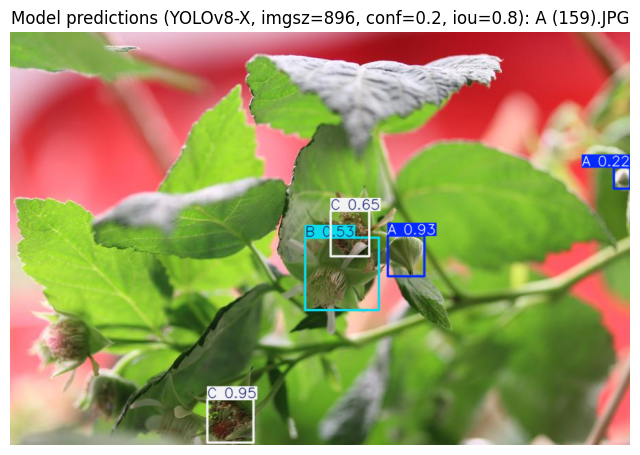

A (160).JPG reference boxes: 9 | predicted boxes: 8


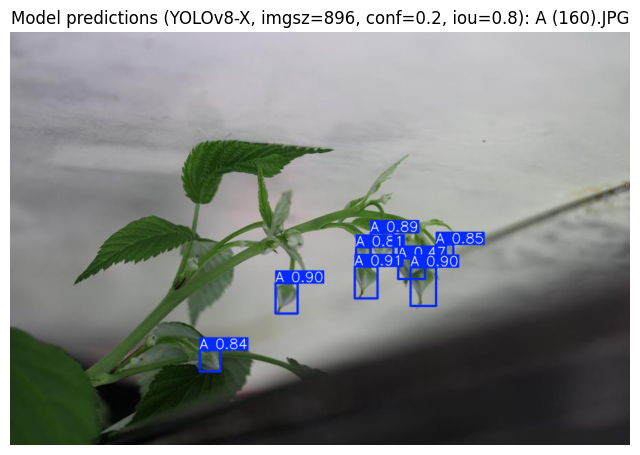

A (161).JPG reference boxes: 5 | predicted boxes: 5


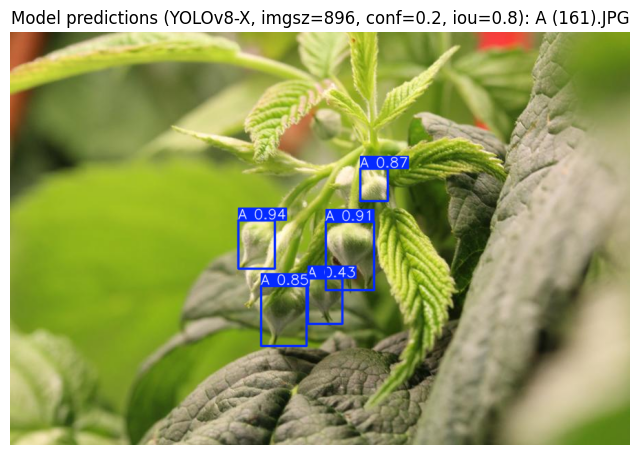

In [ ]:
import os, time
preds = {}
for i, (stem, lbl) in enumerate(zip(stems, demo_lbls)):
    img_path = img_for(stem)
    r = model.predict(source=img_path, imgsz=896, conf=0.2, iou=0.8, device=DEVICE, verbose=False)[0]
    preds[img_path] = r
    print(os.path.basename(img_path), 'reference boxes:', sum(1 for _ in open(lbl)), '| predicted boxes:', len(r.boxes))
    annotated = r.plot()[:, :, ::-1]
    plt.figure(figsize=(8, 6))
    plt.imshow(annotated); plt.axis('off')
    plt.title(f'Model predictions (YOLOv8-X, imgsz=896, conf=0.2, iou=0.8): {os.path.basename(img_path)}')
    plt.show()

## 6. Test-split validation — reproduce the paper's Table V row

Run Ultralytics validation on the released 278-image test split with the authors' training-time validation defaults (`args.yaml`: `imgsz=640`, default `conf=0.001`, `iou=0.7`) — matching how the paper's metrics were produced at the end of training. On CPU this step takes roughly 10–25 minutes.

In [ ]:
import time
t0 = time.time()
metrics = model.val(data='/content/PhenoSet/data.yaml', split='test', imgsz=640, device=DEVICE)
print('validation wall time: %.1fs' % (time.time() - t0))
box = metrics.box
measured = {
    'Precision': float(box.mp), 'Recall': float(box.mr),
    'AP50': float(box.map50), 'mAP50-95': float(box.map),
}
measured['F1'] = 2 * measured['Precision'] * measured['Recall'] / (measured['Precision'] + measured['Recall'])
print(measured)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)


Model summary (fused): 112 layers, 68,130,309 parameters, 0 gradients, 257.4 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1118.9±146.2 MB/s, size: 53.5 KB)


val: Scanning /content/PhenoSet/labels/test... 167 images, 2 backgrounds, 0 corrupt: 60% ━━━━━━━───── 167/278 498.8it/s 0.1s<0.2s

val: Scanning /content/PhenoSet/labels/test... 273 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 278/278 1.7Kit/s 0.2s

...

                     F         44         59      0.751      0.746      0.767      0.597


                     G         33         46      0.531      0.826      0.691      0.586


Speed: 1.8ms preprocess, 38.4ms inference, 0.0ms loss, 0.9ms postprocess per image


Results saved to /content/runs/detect/val


validation wall time: 18.0s
{'Precision': 0.6188949386082913, 'Recall': 0.7198954881706172, 'AP50': 0.6924313817276675, 'mAP50-95': 0.5140135110337998, 'F1': 0.6655853896829778}


### Comparison against the paper (Table V: YOLOv8-x row)

Paper values from ar5iv v1 Table V. Differences are expected and reported as measured: (1) Ultralytics 8.4.174 on Python 3.13 vs the authors' 2024-era stack (an era-matched 8.2.x could not be validated on the current Colab Python); (2) the release ships 5 test images without label files and one duplicate-box label; (3) NMS/evaluation rounding differences. This is a plausibility check against the published row, not an exact-equivalence claim.

In [ ]:
import pandas as pd
paper = {'Precision': 0.721, 'Recall': 0.668, 'AP50': 0.717, 'mAP50-95': 0.550, 'F1': 0.693}
df = pd.DataFrame({'paper (Table V)': paper, 'this run': measured})
df['delta'] = df['this run'] - df['paper (Table V)']
display(df.round(3))
per_class = {model.names[i]: float(m) for i, m in enumerate(box.ap50)}
pc = pd.DataFrame({'per-class AP50 (this run)': per_class}).T
display(pc.round(3))
print('Paper Table VI per-class F1 for comparison: A 0.810, B 0.697, C 0.574, D 0.646, E 0.640, F 0.687, G 0.739')

,paper (Table V),this run,delta
Precision,0.721,0.619,-0.102
Recall,0.668,0.720,0.052
AP50,0.717,0.692,-0.025
mAP50-95,0.550,0.514,-0.036
F1,0.693,0.666,-0.027


,A,B,C,D,E,F,G
per-class AP50 (this run),0.772,0.786,0.469,0.625,0.736,0.767,0.691


Paper Table VI per-class F1 for comparison: A 0.810, B 0.697, C 0.574, D 0.646, E 0.640, F 0.687, G 0.739


### Secondary check — paired images only

The released test folder includes 5 unlabeled images. Re-evaluating on the 273 image/label pairs only shows how much of the difference comes from the release's missing label files rather than from version drift.

In [ ]:
import os, glob, shutil, time
paired_dir = '/content/PhenoSetPaired'
shutil.rmtree(paired_dir, ignore_errors=True)
shutil.copytree('/content/PhenoSet/images/test', paired_dir + '/images/test')
shutil.copytree('/content/PhenoSet/labels/test', paired_dir + '/labels/test')
lbl_stems = {os.path.splitext(f)[0] for f in os.listdir(paired_dir + '/labels/test') if f.endswith('.txt')}
removed = 0
for f in glob.glob(paired_dir + '/images/test/*'):
    if os.path.splitext(os.path.basename(f))[0] not in lbl_stems:
        os.remove(f); removed += 1
cache = paired_dir + '/labels/test.cache'
if os.path.exists(cache):
    os.remove(cache)
print('removed unlabeled images:', removed)
yaml_p = paired_dir + '/data.yaml'
open(yaml_p, 'w').write(f'''path: {paired_dir}
train: images/test
val: images/test
test: images/test
names:
''' + ''.join(f'  {k}: {v}\n' for k, v in model.names.items()))
mp = model.val(data=yaml_p, split='test', imgsz=640, device=DEVICE, verbose=False)
bp = mp.box
measured_paired = {'Precision': float(bp.mp), 'Recall': float(bp.mr), 'AP50': float(bp.map50), 'mAP50-95': float(bp.map)}
measured_paired['F1'] = 2 * measured_paired['Precision'] * measured_paired['Recall'] / (measured_paired['Precision'] + measured_paired['Recall'])
df2 = pd.DataFrame({'paper (Table V)': paper, 'paired-only (273)': measured_paired})
display(df2.round(3))

removed unlabeled images: 5


Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)


Model summary (fused): 112 layers, 68,130,309 parameters, 0 gradients, 257.4 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1135.6±509.3 MB/s, size: 42.7 KB)


val: Scanning /content/PhenoSetPaired/labels/test... 199 images, 2 backgrounds, 0 corrupt: 72% ━━━━━━━━╸─── 199/273 591.7it/s 0.1s<0.1s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 1.5it/s 12.4s

                   all        273       1000      0.631       0.72       0.71      0.528


Speed: 1.6ms preprocess, 38.6ms inference, 0.0ms loss, 0.8ms postprocess per image


Results saved to /content/runs/detect/val-2


,paper (Table V),paired-only (273)
Precision,0.721,0.631
Recall,0.668,0.720
AP50,0.717,0.710
mAP50-95,0.550,0.528
F1,0.693,0.673


## 7. Interpretation and limitations

- What was executed: pretrained inference on 3 test images and full test-split validation of the authors' released YOLOv8-X checkpoint on the Raspberry PhenoSet low-resolution test split (278 released images; 273 image/label pairs).
- Measured agreement with the paper's Table V row is partial: mAP50-95 0.514 (paper 0.550), AP50 0.692 (paper 0.717), with measured recall higher and precision lower than published. Plausible causes are documented above; the largest unexplained factor is the Ultralytics version difference, which we could not eliminate on the current Colab Python.
- What this does **not** verify: the paper's other 10 model configurations, training behavior, segmentation results, dataset-level statistics beyond the test split, and every v2-only claim (field-test accuracy, harvest-forecast lead time), which belong to the unreadable v2 body.
- One validation run is a plausibility check against the published row, not a full benchmark reproduction; differences are reported as measured, not tuned away.

日本語: 実行したのは著者チェックポイントを用いた推論とテスト分割の検証のみです。他モデル・学習・セグメンテーション・v2 の圃場実験は検証対象外であり、Table V との差分は測定値としてそのまま報告します。